<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/8_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 8 — Fine Tuning**

Notebook 7 found MobileNetV2 as the best base model with 75.44% val accuracy
using feature extraction only (frozen base).

Fine tuning takes this further —> we unfreeze the top layers of the base model
and retrain at a very low learning rate, letting the network adapt its
higher-level features specifically to dog breed differences.

## **Why fine tuning works**----->
ImageNet features are general. The top layers of MobileNetV2 learned to detect
things like "fluffy texture" or "pointy ears" for 1000 classes. Fine tuning
nudges these towards the specific visual differences between 120 dog breeds
snout length, ear shape, coat pattern.

## Rules for fine tuning--------->
- Always start from the trained feature extraction model, never from scratch
- Use 10x lower learning rate — large updates destroy pretrained weights
- Unfreeze from the top down — early layers detect edges, they don't need to change

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
dataset_path = os.path.join(path, "images", "Images")

train_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='training',
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='validation',
    seed=42
)

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)

print("Data loaded successfully")

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Data loaded successfully


## **Phase 1 —feature extraction model**
We retrain the feature extraction base first before unfreezing.
This gives fine tuning a strong starting point.

In [ ]:
base_model= keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable=False

inputs= keras.Input(shape=(128,128,3))
x=keras.applications.mobilenet_v2.preprocess_input(inputs)
x=base_model(x,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dropout(0.3)(x)
outputs=layers.Dense(120,activation='softmax')(x)

model = keras.Model(inputs,outputs)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_fe = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

fe_val_acc = max(history_fe.history['val_accuracy'])
print(f"\nFeature Extraction → Best val accuracy: {fe_val_acc:.4f}")

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 93s 146ms/step - accuracy: 0.5880 - loss: 1.5535 - val_accuracy: 0.7393 - val_loss: 0.8962
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.7954 - loss: 0.6570 - val_accuracy: 0.7549 - val_loss: 0.8437
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8522 - loss: 0.4729 - val_accuracy: 0.7510 - val_loss: 0.8547
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.8841 - loss: 0.3621 - val_accuracy: 0.7527 - val_loss: 0.8842
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.9092 - loss: 0.2875 - val_accuracy: 0.7568 - val_loss: 0.8838
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9226 - loss: 0.2445 - val_accuracy: 0.7536 - val_loss: 0.9132
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9349 - loss: 0.2081 - val_accuracy: 0.7532 - val_loss: 0.9352
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9414 - loss: 0.1864 -

## **Phase 2— Unfreeze top layers and fine tune**
Unfreeze the last 20 layers of MobileNetV2.
Recompile at 10x lower learning rate to avoid destroying pretrained weights.

In [ ]:
base_model.trainable= True
for layer in base_model.layers[:-20]:
  layer.trainable =False

print(f'trainable layers={len([l for l in base_model.layers if l.trainable])}')

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_ft=model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

ft_val_acc = max(history_ft.history['val_accuracy'])
print(f"\nFine Tuning → Best val accuracy: {ft_val_acc:.4f}")

trainable layers=20
Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 55s 81ms/step - accuracy: 0.8175 - loss: 0.5581 - val_accuracy: 0.7228 - val_loss: 1.1455
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.8951 - loss: 0.3161 - val_accuracy: 0.7216 - val_loss: 1.1374
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9237 - loss: 0.2239 - val_accuracy: 0.7206 - val_loss: 1.1762
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9416 - loss: 0.1827 - val_accuracy: 0.7206 - val_loss: 1.2002
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9536 - loss: 0.1422 - val_accuracy: 0.7255 - val_loss: 1.2024
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9602 - loss: 0.1257 - val_accuracy: 0.7157 - val_loss: 1.2750
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9633 - loss: 0.1151 - val_accuracy: 0.7104 - val_loss: 1.3520
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.97

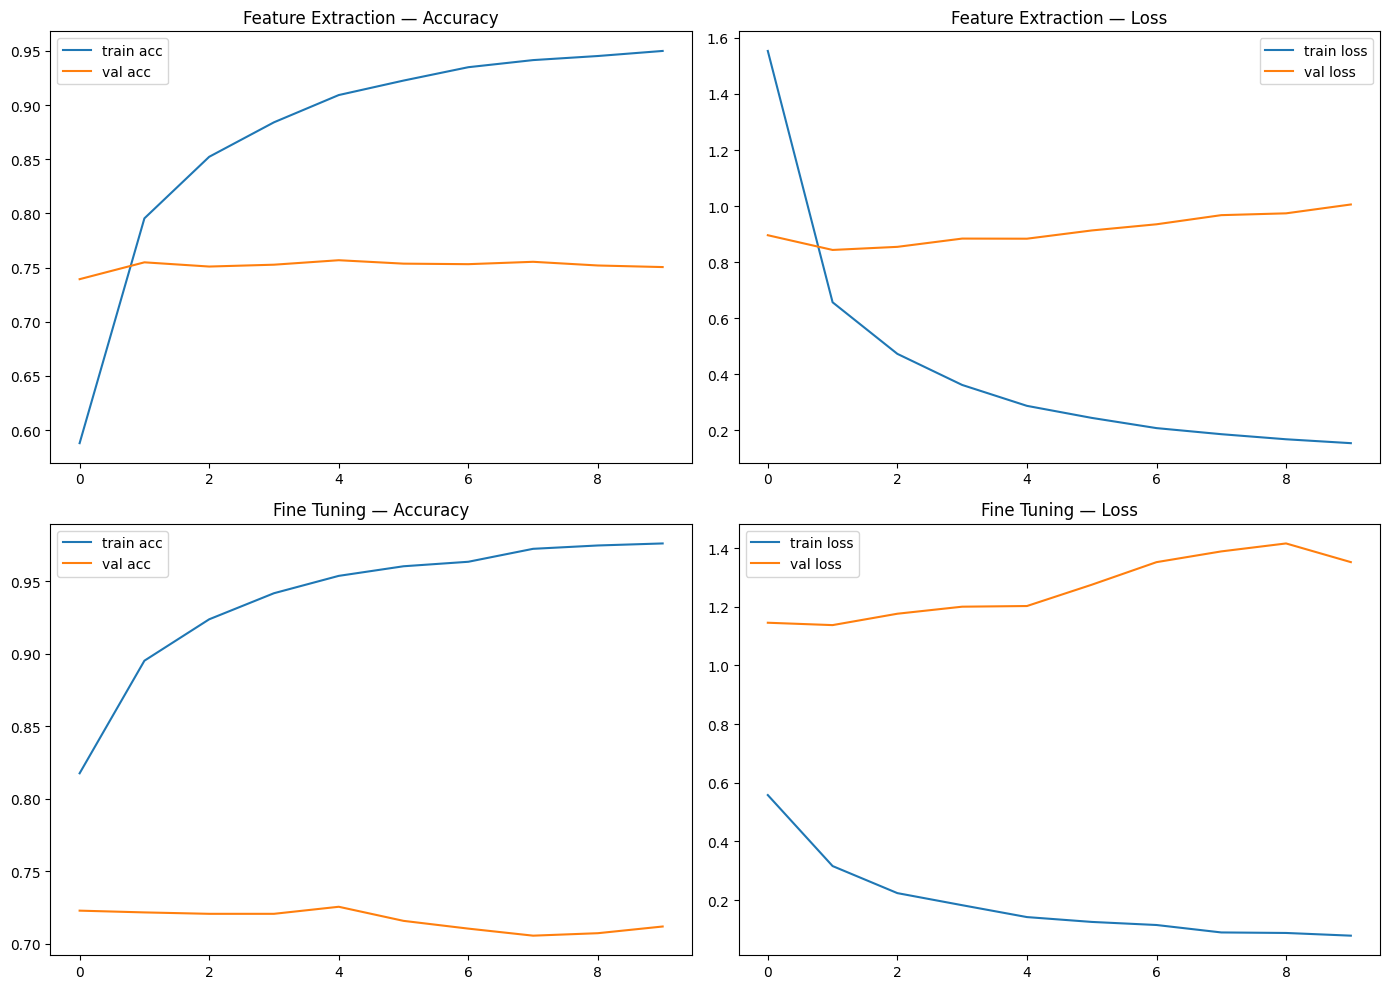

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# feature extraction accuracy
axes[0,0].plot(history_fe.history['accuracy'], label='train acc')
axes[0,0].plot(history_fe.history['val_accuracy'], label='val acc')
axes[0,0].set_title('Feature Extraction — Accuracy')
axes[0,0].legend()

# feature extraction loss
axes[0,1].plot(history_fe.history['loss'], label='train loss')
axes[0,1].plot(history_fe.history['val_loss'], label='val loss')
axes[0,1].set_title('Feature Extraction — Loss')
axes[0,1].legend()

# fine tuning accuracy
axes[1,0].plot(history_ft.history['accuracy'], label='train acc')
axes[1,0].plot(history_ft.history['val_accuracy'], label='val acc')
axes[1,0].set_title('Fine Tuning — Accuracy')
axes[1,0].legend()

# fine tuning loss
axes[1,1].plot(history_ft.history['loss'], label='train loss')
axes[1,1].plot(history_ft.history['val_loss'], label='val loss')
axes[1,1].set_title('Fine Tuning — Loss')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [ ]:
results = {
    'Scratch CNN (baseline)':      0.07,
    'Optuna best (scratch)':       0.1453,
    'MobileNetV2 feature extract': 0.7568,
    'MobileNetV2 fine tuned':      0.7255
}

## Conclusion

| Approach                    | Val Accuracy | Key insight                      |
|-----------------------------|--------------|----------------------------------|
| Scratch CNN baseline        | 7.00%        | Reference point                  |
| Optuna tuned scratch CNN    | 14.53%       | 2x better but still limited      |
| MobileNetV2 feature extract | 75.68%       | Pretrained features are powerful |
| MobileNetV2 fine tuned      | 72.55%       | Fine tuning hurt, not helped     |

Fine tuning vs feature extraction: -3.13%

Surprisingly, fine tuning degraded performance. This happens when:
- The learning rate is still too high — even 0.0001 may have been
  too aggressive for only 20 unfrozen layers
- The feature extraction model hadn't fully converged before unfreezing
- 128×128 input limits how much the top layers can further specialize

The feature extraction result (75.68%) is the best this project achieved
from scratch to transfer learning. The gap vs scratch CNN (~7%) tells
the whole story — pretrained weights matter far more than any amount
of hyperparameter tuning on a weak architecture for this dataset.